In [122]:
import numpy as np
import numpy.typing as npt
from scipy import integrate as intg
import matplotlib.pyplot as plt
import pynumdiff as nd # some submodules requrie cvxpy or tqdm
from pynumdiff import smooth_finite_difference as smoothfd
import itertools
import mysindy

In [69]:
def generate_gaussian_noise(
    std: float, shape: tuple[int, ...]
) -> npt.NDArray[np.float64]:
    """Generate numpy array of Gaussian noise with specified std and array size.

    Parameters
    ----------
    std : float
        Standard deviation of noise.
    shape : tuple[int, ...]
        Size of output array.

    Returns
    -------
    noise : ndarray
        Gaussian noise array, shape given by argument.
    """
    rng = np.random.default_rng()
    noise = rng.normal(scale=std, size=shape)
    return noise

In [ ]:
def lorenz(t, xyz, *, sigma=10, rho=28, beta=8 / 3):
    """Find time derivative of Lorenz attractor at given coordinates x, y, z.

    Parameters
    ----------
    t : any
        Placeholder for syntax compatibility with scipy.integrate.solve_ivp().
    xyz : array-like, shape (3, n)
        n coordinate vectors.
    sigma : float
        Prandtl number.
    rho : float
        Rayleigh number.
    beta : float
        Parameter related to fluid dimensions.

    Returns
    -------
    xyz_dot : array, shape (3, n)
        Time derivatives of x, y, z at the n coordinate vectors.
    """
    x, y, z = xyz
    x_dot = sigma * (y - x)
    y_dot = x * (rho - z) - y
    z_dot = x * y - beta * z
    xyz_dot = np.array([x_dot, y_dot, z_dot])
    return xyz_dot

In [ ]:
def integrate_ode(x_dot_fun, x_0, t_arr, *, args=None, **options):
    """Wrapper of scipy.integrate.solve_ivp() with simpler call signature and output.

    Parameters
    ----------
    x_dot_fun : function
        Time derivative of x, with call signature f(t, x, *args).
    x_0 : array-like, shape (n,)
        Initial value of x.
    t_arr : array-like, shape (n_points,)
        Array of points at which x is evaluated.
    args : tuple, optional
        Extra arguments for x_dot_fun, by default None.
    **options
        Options passed to scipy.integrate.solve_ivp().

    Returns
    -------
    x : ndarray, shape (n, n_points)
        x evaluated at points specified by t_arr.
    """
    t_span = t_arr[[0, -1]]
    solution = intg.solve_ivp(
        x_dot_fun, t_span, x_0, t_eval=t_arr, args=args, **options
    )
    x = solution.y
    return x

In [248]:
def denoise(
    x_list, dt, *, filter_order=4, cutoff_freq=0.025, **options
):
    options["filter_order"] = filter_order
    options["cutoff_freq"] = cutoff_freq

    x_denoised_list = np.zeros_like(x_list)
    x_dot_denoised_list = np.zeros_like(x_list)
    for n in range(len(x_list)):
        x = x_list[n, :]
        x_denoised, x_dot_denoised = smoothfd.butterdiff(x, dt, **options)
        x_denoised_list[n, :] = x_denoised
        x_dot_denoised_list[n, :] = x_dot_denoised

    return x_denoised_list, x_dot_denoised_list

In [249]:
class Trajectory:
    def __init__(self, x_dot_fun, x_0, dt, num_steps, noise_std=0.0):
        self.x_dot_fun = x_dot_fun
        self.x_0 = x_0
        
        self.dt = dt
        self.num_steps = num_steps
        self.t_end = self.dt * self.num_steps
        self.t_arr = np.linspace(0, self.t_end, self.num_steps + 1)
        
        self.x = integrate_ode(self.x_dot_fun, self.x_0, self.t_arr)
        self.x_dot = self.x_dot_fun(None, self.x)
        self.shape = np.shape(self.x)
        
        if noise_std == 0:
            self.x_noisy = self.x
        else:
            self.x_noisy = self.x + generate_gaussian_noise(noise_std, self.shape)
            
        self.x_denoised, self.x_dot_denoised = denoise(self.x_noisy, self.dt)

In [250]:
dt = 1e-3
num_steps = 1 * 10 ** 4

x_0 = np.array([0, 2, 8])
traj = Trajectory(lorenz, x_0, dt, num_steps, 0.1)

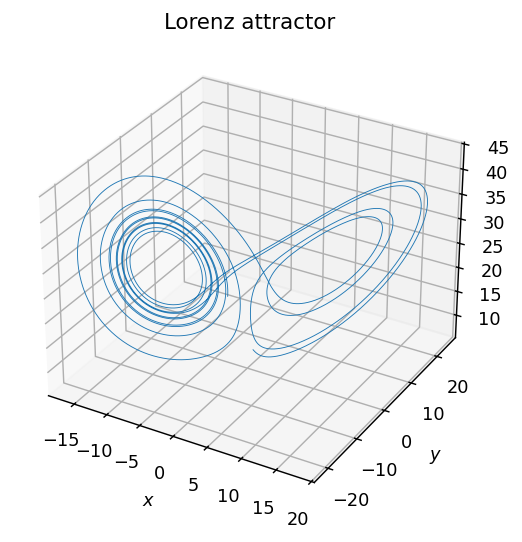

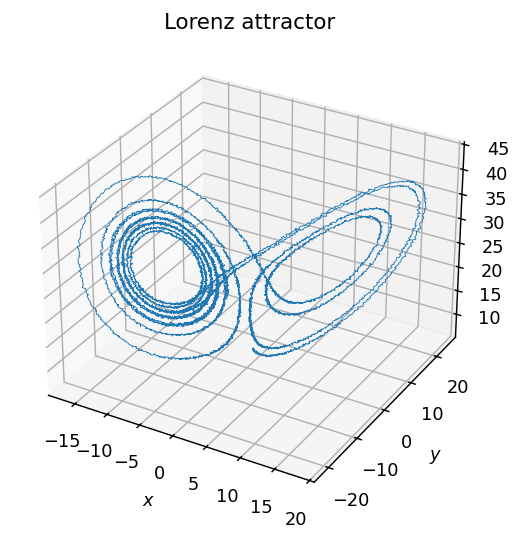

In [251]:
ax = plt.figure(dpi=128).add_subplot(projection="3d")

ax.plot(*traj.x, lw=0.5)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$z$")
ax.set_title("Lorenz attractor")

plt.show()

ax = plt.figure(dpi=128).add_subplot(projection="3d")

ax.plot(*traj.x_noisy, lw=0.5)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$z$")
ax.set_title("Lorenz attractor")

plt.show()

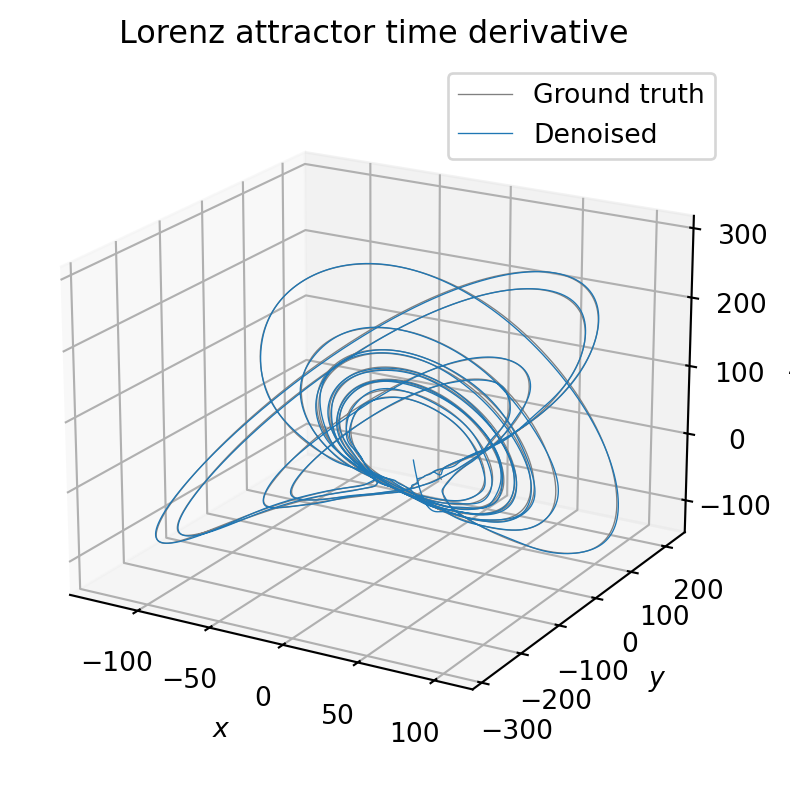

In [252]:
ax = plt.figure(dpi=192).add_subplot(projection="3d")

ax.plot(*traj.x_dot, lw=0.5, color="0.5")
ax.plot(*traj.x_dot_denoised, lw=0.5)
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_zlabel("$z$")
ax.set_title("Lorenz attractor time derivative")
ax.view_init(elev=20, azim=-60)
ax.legend(["Ground truth", "Denoised"])

plt.show()